In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import japanize_matplotlib
import arviz as az

In [2]:
df = pd.read_csv("../data/ili_recent_seasons.csv")
print(df.shape)
df[:5]

(444, 6)


,YEAR,WEEK,% WEIGHTED ILI,ILITOTAL,TOTAL PATIENTS,t_week
0,2018,1,5.77543,47282,879802,0
1,2018,2,5.90830,56922,1026852,1
2,2018,3,6.49095,62937,992379,2
3,2018,4,7.17799,77468,1098998,3
4,2018,5,7.52851,86095,1104089,4


In [3]:
df.groupby("YEAR")["% WEIGHTED ILI"].describe().mean()

count    49.333333
mean      2.526752
std       1.550449
min       0.997437
25%       1.478557
50%       1.878936
75%       3.282169
max       6.758201
dtype: float64

In [4]:
X = df.groupby("YEAR")["% WEIGHTED ILI"].idxmax().values
X

array([  4, 103, 109, 208, 255, 312, 364, 416, 418])

In [5]:
for x in X:
    print(df.iloc[x]["WEEK"])

5.0
52.0
6.0
52.0
47.0
52.0
52.0
52.0
1.0


In [6]:
ili_obs = df["% WEIGHTED ILI"].values
n_weeks = len(ili_obs)
N_pop = 100.0

n_steps_per_week = 50
dt = 1.0 / n_steps_per_week
total_steps = n_steps_per_week * (n_weeks - 1)

t_fine = np.arange(total_steps) * dt

In [7]:

with pm.Model() as sirs_model_v0:
    gamma = pm.Gamma("gamma", alpha=50, beta=50/1)
    xi = pm.Gamma("xi", alpha=50, beta=50/0.02)

    R0_repro = pm.Gamma("R0_repro", mu=1.5, sigma=0.25)

    Beta0 = pm.Deterministic("Beta0", gamma * R0_repro) 
    delta = pm.Beta("delta", alpha=50, beta=50)
    phi = pm.Normal("phi", mu=0, sigma=2)
    epsilon = pm.Gamma("epsilon", alpha=50, beta=50/0.5)

    I0 = pm.Deterministic("I0", ili_obs[0] / gamma)
    R_init_frac = pm.Beta("R_init_frac", alpha=2, beta=2)
    R_init = pm.Deterministic("R_init", R_init_frac * (N_pop - I0))
    

    def euler_step(t_now, I_prev, R_prev, Beta0, delta, phi, gamma, xi, N, dt):
            beta_t = Beta0 * (1 + delta * pt.cos(2 * np.pi * t_now/52- phi))
            S_prev = N - I_prev - R_prev
            dI = (beta_t * S_prev * I_prev / N - gamma * I_prev) * dt
            dR = (gamma * I_prev - xi * R_prev) * dt
            I_new = pt.clip(I_prev +  dI, 0.0, N)
            R_new = pt.clip(R_prev +  dR, 0.0, N)
            return I_new, R_new

    (I_path, R_path), _ = pytensor.scan(
        fn=euler_step,
        sequences=[pt.as_tensor_variable(t_fine)],
        outputs_info=[I0, R_init],
        non_sequences=[Beta0, delta, phi, gamma, xi, N_pop, dt],
        n_steps=total_steps,
    )

    idx = pt.arange(n_steps_per_week - 1, total_steps, n_steps_per_week)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    rate_param = pm.Deterministic("rate_param", epsilon / pt.clip(I_pred, 0.01, N_pop))
    pm.Gamma("obs", alpha=epsilon, beta=rate_param, observed=ili_obs)
    
    
    
    
    

/tmp/ipykernel_105888/1664125002.py:26: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  (I_path, R_path), _ = pytensor.scan(


/home/manaty/baysian-epidemiological-models/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2978: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


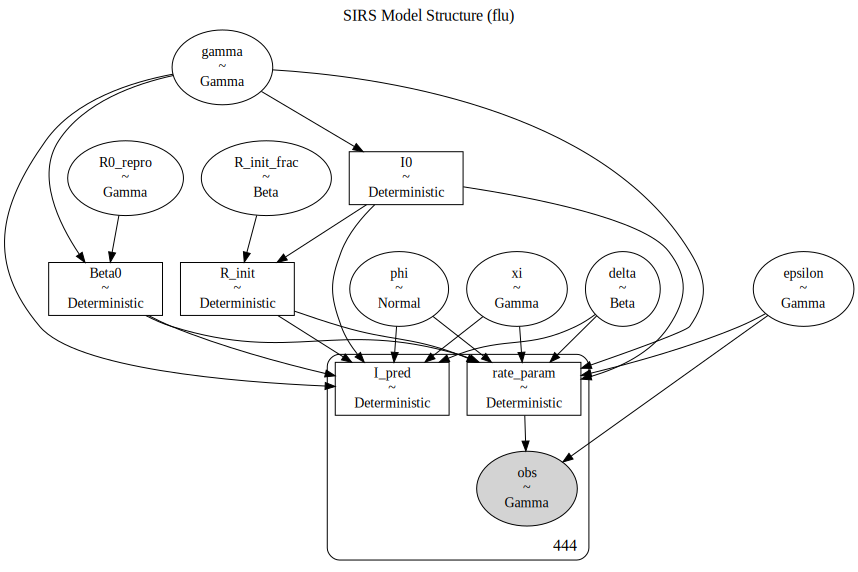

In [8]:
g_v0 = pm.model_to_graphviz(sirs_model_v0)
g_v0.graph_attr.update(
    label="SIRS Model Structure (flu)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

g_v0.render(filename="../models/sirs_model_graph", format="png", cleanup=True)
g_v0

In [9]:
with sirs_model_v0:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [R0_repro, R_init_frac, delta, epsilon, gamma, obs, phi, xi]


I_pred の統計:
  最小値: 7.9744959824655285e-28
  最大値: 21.287966831385706
  99percentile: 11.052578881396906

Beta0: 平均= 1.516455130678971 範囲=[ 0.7466230961255091 , 2.721729020842642 ]
delta: 平均= 0.5040492670417943 範囲=[ 0.3811289538227772 , 0.6503119059921193 ]

R0_repro: 1を超える割合= 0.99 平均= 1.5033522853199421


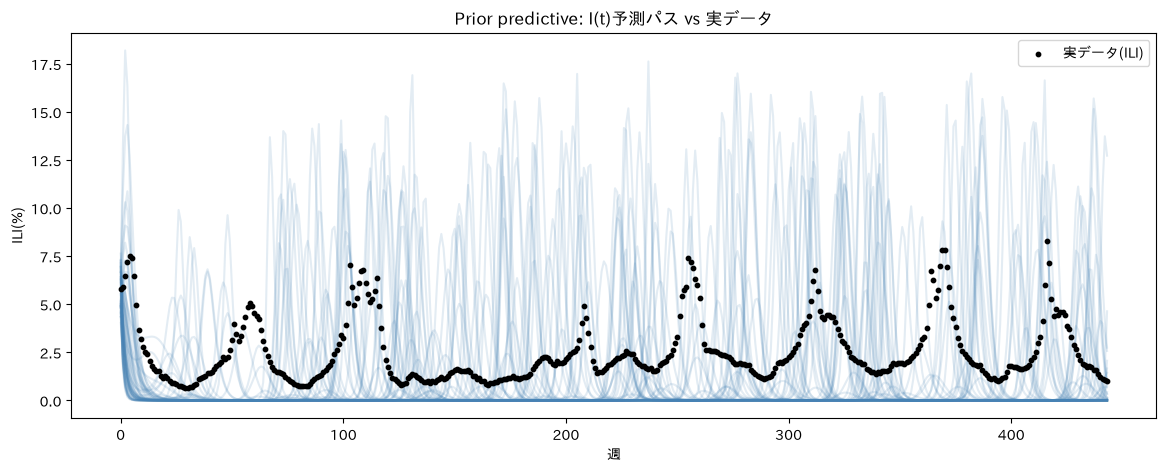

In [10]:
I_pred_prior = prior.prior["I_pred"].values.reshape(-1, n_weeks)

fig, ax = plt.subplots(figsize=(14, 5))
for i in range(60):
    ax.plot(df["t_week"], I_pred_prior[i], color="steelblue", alpha=0.15)
ax.scatter(df["t_week"], ili_obs, color="black", s=10, zorder=5, label="実データ(ILI)")
ax.set_xlabel("週"); ax.set_ylabel("ILI(%)")
ax.legend()
ax.set_title("Prior predictive: I(t)予測パス vs 実データ")
plt.savefig("../img/sirs_prior_check_v0.png", dpi=100)

print("I_pred の統計:")
print("  最小値:", I_pred_prior.min())
print("  最大値:", I_pred_prior.max())
print("  99percentile:", np.percentile(I_pred_prior, 99))

Beta0_prior = prior.prior["Beta0"].values.flatten()
delta_prior = prior.prior["delta"].values.flatten()
print("\nBeta0: 平均=", Beta0_prior.mean(), "範囲=[", Beta0_prior.min(), ",", Beta0_prior.max(), "]")
print("delta: 平均=", delta_prior.mean(), "範囲=[", delta_prior.min(), ",", delta_prior.max(), "]")

R0_prior = prior.prior["R0_repro"].values.flatten()
print("\nR0_repro: 1を超える割合=", (R0_prior > 1).mean(), "平均=", R0_prior.mean())

In [11]:
#R0(基本再生産数)の1.0以下の異常値を防ぐために、R0を最低0.8を担保
#deltaの平均を0.5から0.3に
with pm.Model() as sirs_model_v1:
    gamma = pm.Gamma("gamma", alpha=50, beta=50/1)
    xi = pm.Gamma("xi", alpha=50, beta=50/0.02)

    eps = pm.Gamma("eps", alpha=50, beta=50/0.4)
    R0_repro = pm.Deterministic("R0_repro",0.8 + eps)

    Beta0 = pm.Deterministic("Beta0", gamma * R0_repro) 
    delta = pm.Beta("delta", alpha=30, beta=70)
    phi = pm.Normal("phi", mu=0, sigma=2)
    epsilon = pm.Gamma("epsilon", alpha=50, beta=50/0.5)

    I0 = pm.Deterministic("I0", ili_obs[0] / gamma)
    R_init_frac = pm.Beta("R_init_frac", alpha=2, beta=2)
    R_init = pm.Deterministic("R_init", R_init_frac * (N_pop - I0))
    

    def euler_step(t_now, I_prev, R_prev, Beta0, delta, phi, gamma, xi, N, dt):
            beta_t = Beta0 * (1 + delta * pt.cos(2 * np.pi * t_now/52- phi))
            S_prev = N - I_prev - R_prev
            dI = (beta_t * S_prev * I_prev / N - gamma * I_prev) * dt
            dR = (gamma * I_prev - xi * R_prev) * dt
            I_new = pt.clip(I_prev +  dI, 0.0, N)
            R_new = pt.clip(R_prev +  dR, 0.0, N)
            return I_new, R_new

    (I_path, R_path), _ = pytensor.scan(
        fn=euler_step,
        sequences=[pt.as_tensor_variable(t_fine)],
        outputs_info=[I0, R_init],
        non_sequences=[Beta0, delta, phi, gamma, xi, N_pop, dt],
        n_steps=total_steps,
    )

    idx = pt.arange(n_steps_per_week - 1, total_steps, n_steps_per_week)
    I_pred = pt.concatenate([[I0], I_path[idx]])
    pm.Deterministic("I_pred", I_pred)

    rate_param = pm.Deterministic("rate_param", epsilon / pt.clip(I_pred, 0.01, N_pop))
    pm.Gamma("obs", alpha=epsilon, beta=rate_param, observed=ili_obs)
    
    
    
    
    

/tmp/ipykernel_105888/3469682229.py:29: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  (I_path, R_path), _ = pytensor.scan(


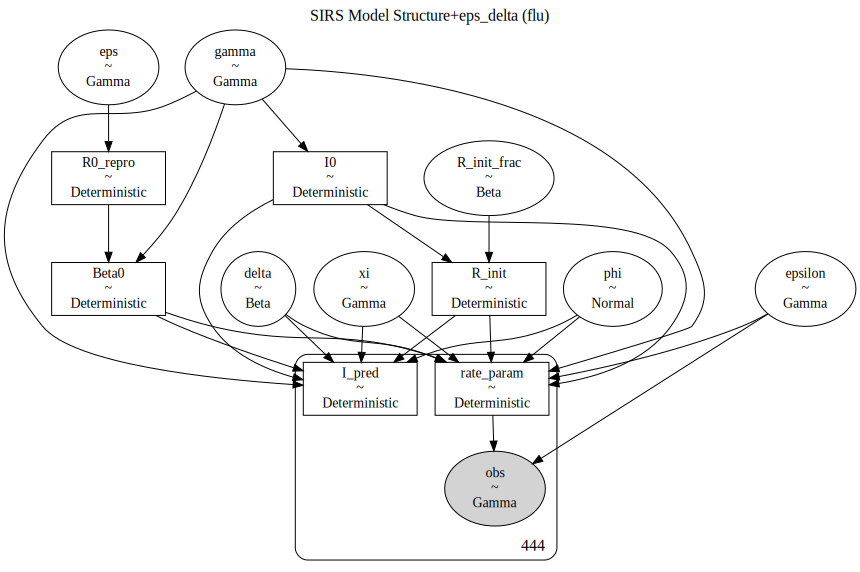

In [12]:
g_v1 = pm.model_to_graphviz(sirs_model_v1)
g_v1.graph_attr.update(
    label="SIRS Model Structure+eps_delta (flu)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

g_v1.render(filename="../models/sirs_model_graph_eps_delta", format="png", cleanup=True)
g_v1

In [13]:
with sirs_model_v1:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [R_init_frac, delta, eps, epsilon, gamma, obs, phi, xi]


I_pred の統計:
  最小値: 5.312191206706917e-21
  最大値: 9.685165854672062
  99percentile: 4.842407397140167

Beta0: 平均= 1.209509408639272 範囲=[ 0.7750131853672415 , 1.9156511756839534 ]
delta: 平均= 0.3002860075543867 範囲=[ 0.19843622947627612 , 0.4448003944346165 ]

R0_repro: 1を超える割合= 1.0 平均= 1.2008148722099066


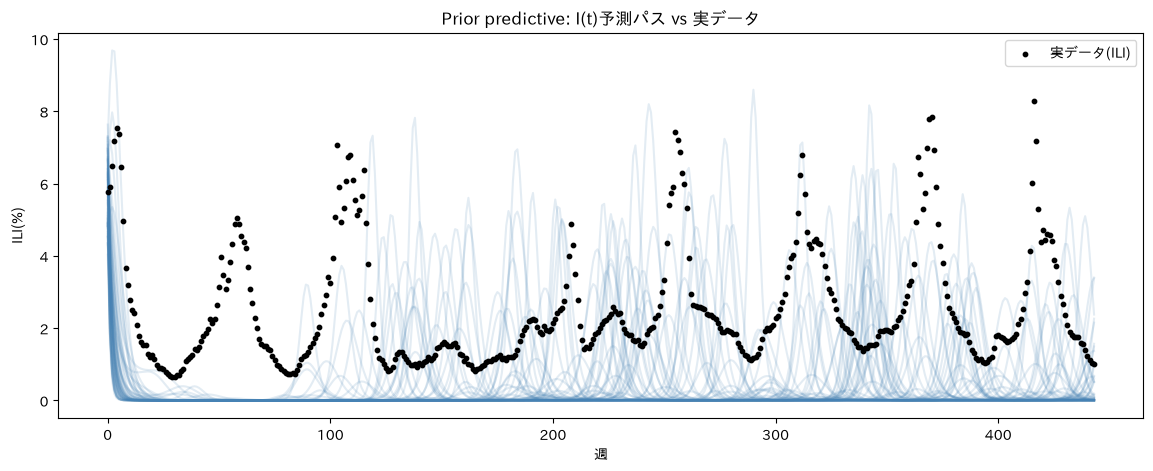

In [15]:
I_pred_prior = prior.prior["I_pred"].values.reshape(-1, n_weeks)

fig, ax = plt.subplots(figsize=(14, 5))
for i in range(60):
    ax.plot(df["t_week"], I_pred_prior[i], color="steelblue", alpha=0.15)
ax.scatter(df["t_week"], ili_obs, color="black", s=10, zorder=5, label="実データ(ILI)")
ax.set_xlabel("週"); ax.set_ylabel("ILI(%)")
ax.legend()
ax.set_title("Prior predictive: I(t)予測パス vs 実データ")
plt.savefig("../img/sirs_prior_check_v1.png", dpi=100)

print("I_pred の統計:")
print("  最小値:", I_pred_prior.min())
print("  最大値:", I_pred_prior.max())
print("  99percentile:", np.percentile(I_pred_prior, 99))

Beta0_prior = prior.prior["Beta0"].values.flatten()
delta_prior = prior.prior["delta"].values.flatten()
print("\nBeta0: 平均=", Beta0_prior.mean(), "範囲=[", Beta0_prior.min(), ",", Beta0_prior.max(), "]")
print("delta: 平均=", delta_prior.mean(), "範囲=[", delta_prior.min(), ",", delta_prior.max(), "]")

R0_prior = prior.prior["R0_repro"].values.flatten()
print("\nR0_repro: 1を超える割合=", (R0_prior > 1).mean(), "平均=", R0_prior.mean())

In [16]:
with sirs_model_v1:
    idata = pm.sample(draw=2000, tune=2000, chains=4, cores=4, target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

NUTS[numpyro]: [gamma, xi, eps, delta, phi, epsilon, R_init_frac]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%| | 0/3000 [00:00
  0%|     | 0/3000 [00:00<?, ?it/s]
Compiling.. :   0%| | 0/3000 [00:00

  0%|     | 0/3000 [00:00<?, ?it/s]

Compiling.. :   0%| | 0/3000 [00:00


  0%|     | 0/3000 [00:00<?, ?it/s]


Running chain 0:   0%| | 0/3000 [00
Running chain 1:   0%| | 0/3000 [00

Running chain 2:   0%| | 0/3000 [00


Running chain 3:   0%| | 0/3000 [00

Running chain 2:   5%| | 150/3000 [


Running chain 3:   5%| | 150/3000 [
Running chain 1:   5%| | 150/3000 [

Running chain 2:  10%| | 300/3000 [
Running chain 1:  10%| | 300/3000 [


Running chain 3:  10%| | 300/3000 [

Running chain 2:  15%|▏| 450/3000 [
Running chain 1:  15%|▏| 450/3000 [


Running chain 3:  15%|▏| 450/3000 [

Running chain 2:  20%|▏| 600/3000 [
Running chain 1:  20%|▏| 600/3000 [


Running chain 3:  20%|▏| 600/3000 [

Running c

In [17]:
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=["gamma", "xi", "R0_repro", "delta", "phi", "eps"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gamma,0.346,0.029,0.31,0.39,1435,985,1.00,0.00094,0.0012
xi,0.0375,0.00296,0.033,0.042,1963,2178,1.00,6.7e-05,4.8e-05
R0_repro,1.362,0.04,1.3,1.4,1593,1347,1.00,0.0011,0.0013
delta,0.189,0.027,0.15,0.23,1444,1035,1.00,0.00076,0.00063
phi,-1.146,0.093,-1.3,-1,1822,1455,1.00,0.0026,0.0034
eps,0.562,0.04,0.51,0.63,1593,1347,1.00,0.0011,0.0013


# 米国季節性インフルエンザ(ILI, 2018-2026) SIRS機構モデル セッションサマリー

## 目的

SIR(Eyam)→SIS(ナイジェリア・マラリア)に続く機構論的モデルの第3弾。**季節性を持つ、免疫が時間とともに薄れる感染症**をSIRSモデルで表現する。これまでの「時間一定のパラメータ」から「時間変動する感染率β(t)」への拡張が、このセッションの核心テーマとなった。

## データ取得

- CDC FluView(ILINet)の週次データ。動的ダッシュボード(gis.cdc.gov/grasp)からのユーザー自身によるダウンロードで取得(Kirby Institute・USGS地震データに続き、3度目のダッシュボード形式データだったが、今回はダウンロード機能を案内する形でスムーズに解決)。
- 1997-2026年、全国区間の週次`% WEIGHTED ILI`(インフルエンザ様疾患の医療機関受診割合)。全期間で29年分の明確な周期(冬季ピーク・夏季収束)を確認した上で、2018-2026年(444週)を分析対象とした。

## モデル構造

$$\frac{dS}{dt}=-\beta(t)SI/N+\xi R, \quad \frac{dI}{dt}=\beta(t)SI/N-\gamma I, \quad \frac{dR}{dt}=\gamma I-\xi R$$
$$\beta(t)=\beta_0(1+\delta\cos(2\pi t/52-\phi))$$

- SIS(マラリア)からの拡張点は2つ: ①$R$コンパートメントの復活(SIR同様)と、免疫喪失$\xi R$によるSへの回帰(SIRS特有)、②$\beta$の時間依存化(季節性)。
- `pytensor.scan`の`sequences`引数(これまでの`non_sequences`と異なり、ステップごとに異なる値を渡せる)を初めて活用し、各細分化ステップの時刻を`euler_step`に渡すことで季節変動を実装。

## パラメータ設計における一連の誤りと修正(このセッションの中心的な学び)

複数の誤りが連続して発生し、その都度修正した:

1. **観測水準とモデルパラメータの混同**: 「observed ILIの平均2.5%」をそのまま$\beta_0$に使おうとした誤り(マラリアのときと同型の誤り)。$\beta$は$SI/N$に掛かる係数であり観測値の水準とは別物であることを再確認。
2. **γの単位の取り違え**: 「感染期間1週間」から$\gamma=52$と逆に計算(週単位のデータでは$\gamma=1$が正しい)。
3. **Gamma分布のalpha<1の危険性の再確認**: 一時`alpha=0.01`のような極端に小さい値を設定し、0付近で密度が発散する分布になっていたことを指摘・修正。Hawkes過程やサメで確立した「0近辺の密度を避ける」原則が、ここでも通用することを再確認。
4. **HalfNormalとGammaの使い分け**: 「中心をずらせない($\propto\sigma$)HalfNormal」と「平均・分散を独立に指定できるGamma」の違いを整理し、$R_0$の中心を1.5に置く目的にはGammaが適切と判断。
5. **Beta分布の平均の式の誤り**: `alpha=50,beta=50/0.5=100`という、Gamma分布の平均の式($\alpha/\beta$)をBeta分布(平均$\alpha/(\alpha+\beta)$)に誤用。$\alpha=\beta$で平均0.5、と修正。
6. **変数名の衝突**: 基本再生産数の`R0`と、SIRSコンパートメントの`R`(免疫保持者)の初期値を区別せず命名しようとした誤りを事前に回避。

## Prior predictive checkでの新しい病理: 季節変動パラメータの組み合わせによる暴走

### 第一段階: 周期異常(見かけ上の高頻度スパイク)

`sequences`に渡す時刻配列の単位誤りを疑ったが、実際にはコード自体は正しく、**真の原因はオイラー法の数値不安定性ではないか**という仮説を立てた。

### 第二段階: 仮説の反証

`n_steps_per_week`を10→50に増やし(数値積分をより細かく)検証したが、スパイクの激しさはほとんど変化せず、**「数値積分精度の問題」という仮説は反証された**。

### 第三段階: 真の原因の特定

$\beta(t)=\beta_0(1+\delta\cos(\cdots))$の**最大値**を検算したところ、事前分布サンプルの組み合わせ次第で$R_0(t)_{\max}\approx4.5$に達しうることが判明。季節性インフルエンザの文献的$R_0$(1〜2程度)を大きく超える値で、**$\beta_0$と$\delta$という個々には妥当に見えるパラメータの"組み合わせ"が、$R_0(t)$の変動幅を過度に大きくしていた**、というSISの$R_0=1+\epsilon$のときと同型だが、今回は「時間変動する比」という一段複雑な形で現れた病理。

### 対処: R0=1+εへの再パラメータ化+δの分散調整

$R_0=0.8+\epsilon$(SISと異なり中心を1.2〜1.4程度に設定、マラリアのような1への極端な集中は不要と判断)、$\delta\sim\text{Beta}(\alpha=30,\beta=70)$(平均0.3、分散を大幅に締める)という組み合わせで、$R_0(t)_{\min}=R_0(1-\delta)$が1を明確に下回る(≈0.84)ように調整。段階的な検算(delta=0.1では$R_0(t)_{\min}>1$となり季節性の"谷"が消えることを解析的に予測・的中)を経て、暴走(最大値849相当→10.4)を収束させた。

## サンプリング結果

- 診断: r_hat=1.00、divergences=0、ess千超(4コンパートメント・季節変動という複雑な構造にもかかわらず健全)
- $\gamma\approx0.346$($1/\gamma\approx2.9$週): 事前分布(平均1、感染期間1週間)から大きく下方修正。ILIという指標が「症状の残る期間」を反映しやすいことと整合的な、データからの新しい知見。
- $\xi\approx0.0375$($1/\xi\approx26.7$週≈半年強): 事前分布(1年)より短く、免疫の減衰が想定より速いことを示唆。
- $R_0\_repro\approx1.362$、$\delta\approx0.189$: ともに事前分布の中心から動いたが、$R_0(t)_{\min}=1.362\times(1-0.189)\approx1.10$と、季節性の谷でも1をわずかに上回る結果に。**「観測データは夏に明確に減少するが、モデルのR0(t)は年間を通じて1を超えたまま」という一見矛盾する結果**が最後に浮かび上がり、$R_0(t)>1$(増加方向)であることと観測ILIの絶対的な"高さ"は別の話である、という考察を残して次回への課題とした。
- $\phi\approx-1.146$ラジアン(≈-9.5週、10月末〜11月頭のピーク): 実際のインフルエンザ流行開始時期と良く整合。

---

## 主要な学び

1. **`pytensor.scan`の`sequences`引数で、時間変動するパラメータをモデルに組み込む新パターンを習得**: これまでの`non_sequences`(全ステップ共通)との違いを理解し、季節性のような周期的な外部駆動をODEに組み込む手法を確立。
2. **「個々のパラメータは妥当でも、組み合わせ(比・積・振幅)が現実離れする」という病理は、時間変動パラメータでも同型に現れる**: SISのR0、Hawkes過程のM(分岐比)に続き、SIRSでは「時間変動するR0(t)の最大値・最小値」という、より込み入った形でこの病理が再登場した。数値積分の精度不足という別の仮説を検証・反証するプロセスを経て、真因(パラメータ組み合わせ)にたどり着いた点が今回の診断プロセスの見どころ。
3. **反証によって仮説を1つずつ消していく診断の型が、複雑なモデルほど有効**: 「時刻配列の単位誤り」「数値積分精度」という2つの仮説を、コード確認とn_steps_per_weekを増やす実験でそれぞれ反証し、最終的に「パラメータの組み合わせ」という正しい原因にたどり着いた。原因を決め打ちせず、検証可能な仮説を順に潰していくプロセスは、これまでのセッション全体を通じて確立してきた方法論の集大成といえる。
4. **モデルの残された謎を、無理に解決せず次回への課題として明示する**: 「R0(t)が年間を通じて1を超えているのに、観測データは夏に大きく減少する」という一見矛盾する結果を、単純化せず、"R0(t)の符号"と"観測量の絶対水準"は別の情報である、という考察を添えて保留した。全てを即座に説明しきろうとせず、疑問点を疑問点のまま正直に記録する姿勢。

## SIR→SIS→SIRSを通じての位置づけ

3つの機構論的モデルを通じ、パラメータのスケール感を「データから逆算する」手順(Eyamのβ検算、マラリアの平衡水準からのR0逆算、インフルエンザのR0(t)最大/最小の検算)が一貫して有効だったことを確認した。次回のSEIR(部分観測系、Eが直接観測されない)では、これまでとは異なる種類の識別性の課題に直面すると予想される。
